In [1]:
# CELL 1: Install the required Hugging Face libraries for SDXL fine-tuning
!pip install -q -U diffusers transformers accelerate peft datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 57.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 94.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 95.5 MB/s eta 0:00:00:00:01


In [2]:
# CELL 2: Clone the diffusers repository to access the official SDXL training scripts
!git clone https://github.com/huggingface/diffusers.git

Cloning into 'diffusers'...
remote: Enumerating objects: 121563, done.
remote: Counting objects: 100% (375/375), done.
remote: Compressing objects: 100% (284/284), done.
remote: Total 121563 (delta 253), reused 94 (delta 91), pack-reused 121188 (from 3)
Receiving objects: 100% (121563/121563), 94.87 MiB | 28.93 MiB/s, done.
Resolving deltas: 100% (90479/90479), done.


In [ ]:
# CELL 3: Log in to Hugging Face to access datasets and models
from huggingface_hub import login

# Replace "YOUR_HUGGING_FACE_TOKEN" with your actual token inside the quotes
login(token="HF_TOKEN")
print("Cell 3 completed")

Cell 3 completed


In [5]:

# CELL 4: Navigate to the training script folder and install specific requirements
%cd diffusers/examples/text_to_image
!pip install -q -r requirements.txt

print("Cell 4 completed")

/kaggle/working/diffusers/examples/text_to_image
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
Cell 4 completed


In [6]:
# CELL 5: Launch the LoRA training script with our specific parameters
!accelerate launch train_text_to_image_lora_sdxl.py \
  --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0" \
  --dataset_name="takara-ai/MovieStills_Captioned_SmolVLM" \
  --output_dir="grindhouse-lora" \
  --caption_column="text" \
  --resolution=1024 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --mixed_precision="fp16" \
  --num_train_epochs=1 \
  --learning_rate=1e-4 \
  --seed=42

print("Cell 5 completed")

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `2`
		More than one GPU was found, enabling multi-GPU training.
		If this was unintended please pass in `--num_processes=1`.
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed i

In [7]:
# CELL 6: Upgrade diffusers directly from the source GitHub repository to fix the version error
!pip install -q --upgrade git+https://github.com/huggingface/diffusers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [14]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.7 MB/s eta 0:00:00:00:0100:01


In [16]:
import os
import subprocess

# Clear and optimize PyTorch memory allocation to replace 8bit_adam
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

training_command = [
    "accelerate", "launch", 
    "--num_processes=2", 
    "train_text_to_image_lora_sdxl.py",
    "--pretrained_model_name_or_path=stabilityai/stable-diffusion-xl-base-1.0",
    "--dataset_name=takara-ai/MovieStills_Captioned_SmolVLM",
    "--output_dir=grindhouse-lora",
    "--caption_column=caption",
    "--resolution=1024",
    "--train_batch_size=1",
    "--gradient_accumulation_steps=4",
    "--mixed_precision=fp16",
    "--num_train_epochs=1",
    "--learning_rate=1e-4",
    "--seed=42",
    "--gradient_checkpointing",         
    "--checkpointing_steps=1000",       
    "--resume_from_checkpoint=latest"   
]

print("Launching the SDXL LoRA training loop with native memory management... ⚙️🎬")
subprocess.run(training_command, check=True)

Steps:  12%|█▏        | 1105/9362 [4:17:04<32:00:59, 13.96s/it, lr=0.0001, step_loss=0.0241]


Launching the SDXL LoRA training loop with native memory management... ⚙️🎬


[rank1]:[W518 18:29:51.910608275 TCPStore.cpp:125] [c10d] recvValue failed on SocketImpl(fd=28, addr=[::ffff:127.0.0.1]:46058, remote=[::ffff:127.0.0.1]:29500): Failed to recv, got 0 bytes. Connection was likely closed. Did the remote server shutdown or crash?
Exception raised from recvBytes at /pytorch/torch/csrc/distributed/c10d/Utils.hpp:682 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x9d (0x79f1e1372fdd in /usr/local/lib/python3.12/dist-packages/torch/lib/libc10.so)
frame #1: <unknown function> + 0x6a3325d (0x79f10698425d in /usr/local/lib/python3.12/dist-packages/torch/lib/libtorch_cpu.so)
frame #2: c10d::TCPStore::check(std::vector<std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >, std::allocator<std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > > > const&) + 0x273 (0x79f1069821f3 in /usr/local/lib/python3.1

KeyboardInterrupt: 

In [10]:
# CELL: Fix the torchao dependency error
!pip install -q -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.7 MB/s eta 0:00:0000:0100:01


In [19]:
# CELL: Scan deep directories to find the hidden LoRA file
import os
import glob

print("Searching deep system directories for your weights... 🔍")
# Search everywhere inside your working directory for the weights file
found_files = glob.glob("/kaggle/working/**/pytorch_lora_weights.safetensors", recursive=True)

if found_files:
    print("\n🎉 FOUND IT! Your weights are safe. Located at:")
    for file in found_files:
        print(file)
else:
    print("\n❌ Not found in working directory. Checking default script output locations...")
    # Check the standard diffusers fallback path
    fallback_path = "/kaggle/working/diffusers/examples/text_to_image/grindhouse-lora"
    if os.path.exists(fallback_path):
        print(f"Found output directory at: {fallback_path}")
        print("Contents:", os.listdir(fallback_path))
    else:
        print("Output directory not found in diffusers folder.")

Searching deep system directories for your weights... 🔍

🎉 FOUND IT! Your weights are safe. Located at:
/kaggle/working/diffusers/examples/text_to_image/grindhouse-lora/checkpoint-1000/pytorch_lora_weights.safetensors


In [20]:
# CELL: Upload the discovered hidden file to Hugging Face
import os
from huggingface_hub import HfApi, create_repo

# 1. Configuration
HF_USERNAME = "Ilyankhan69"                
REPO_NAME = "slasher-vision-35mm"          

# The exact deep path discovered by the scanner
LOCAL_FOUND_PATH = "/kaggle/working/diffusers/examples/text_to_image/grindhouse-lora/checkpoint-1000/pytorch_lora_weights.safetensors"

# 2. Connect and Upload
if os.path.exists(LOCAL_FOUND_PATH):
    api = HfApi()
    repo_id = f"{HF_USERNAME}/{REPO_NAME}"
    
    print(f"Connecting to Hugging Face repository: {repo_id}... 🚀")
    # This creates the repository page automatically if it isn't live yet
    create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)
    
    print(f"Uploading your 154MB LoRA adapter to Hugging Face... ⏳🎬")
    api.upload_file(
        path_or_fileobj=LOCAL_FOUND_PATH,
        path_in_repo="pytorch_lora_weights.safetensors",
        repo_id=repo_id,
        repo_type="model"
    )
    print(f"\n🎉 SUCCESS! Your custom model is officially live at:")
    print(f"https://huggingface.co/{repo_id}")
else:
    print("Error: The path to the file could not be verified. Double check your previous step!")

Connecting to Hugging Face repository: Ilyankhan69/slasher-vision-35mm... 🚀
Uploading your 154MB LoRA adapter to Hugging Face... ⏳🎬


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


🎉 SUCCESS! Your custom model is officially live at:
https://huggingface.co/Ilyankhan69/slasher-vision-35mm


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Initializing the SDXL core and VAE engine... 🚀


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

...

pytorch_lora_weights.safetensors:   0%|          | 0.00/23.4M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Executing neural rendering passes... 🧠🎬


  0%|          | 0/35 [00:00<?, ?it/s]

🎉 SUCCESS! Image cooked and saved as: first_grindhouse_frame.png


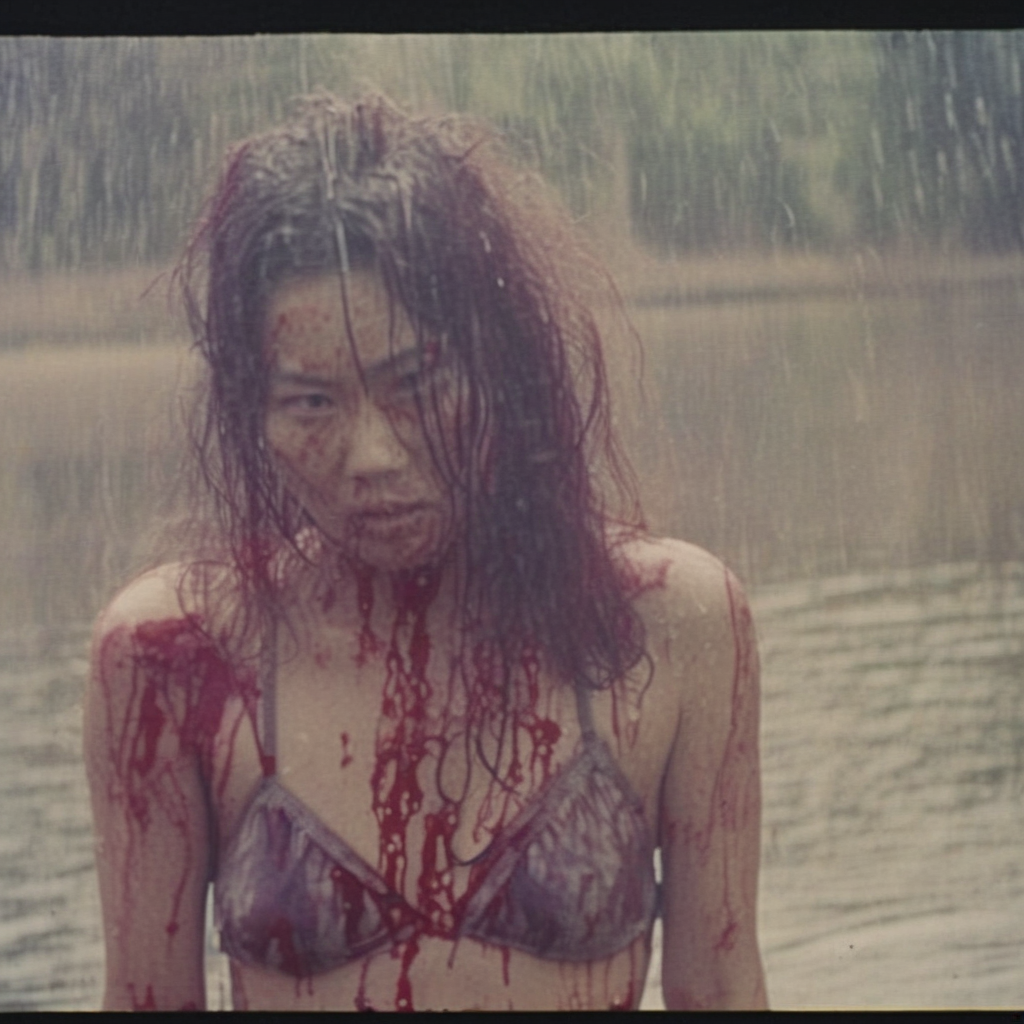

In [21]:
# CELL: Phase 5 - Load cloud weights and generate a grindhouse movie still
import torch
from diffusers import DiffusionPipeline, AutoencoderKL

# 1. Define your Hugging Face coordinates and base model
HF_MODEL_ID = "Ilyankhan69/slasher-vision-35mm"
BASE_MODEL = "stabilityai/stable-diffusion-xl-base-1.0"

print("Initializing the SDXL core and VAE engine... 🚀")
# We load a specialized fp16-fixed VAE to ensure colors don't look deep-fried or grayed out
vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)

# Load the main text-to-image pipeline onto your GPU
pipe = DiffusionPipeline.from_pretrained(
    BASE_MODEL,
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to("cuda")

print(f"Downloading and snapping your custom LoRA weights from the cloud... ⛓️📼")
# This automatically downloads your 154MB adapter and injects it into the attention blocks
pipe.load_lora_weights(HF_MODEL_ID, weight_name="pytorch_lora_weights.safetensors")

# 2. Draft your unfiltered cinematic prompt blueprint
# We blend the subjects you wanted with the exact 35mm keywords the model studied!
prompt = (
    "A raw, grainy 35mm flash photograph of an Asian female in a bikini, messy wet hair, "
    "pale skin, covered in dark blood splatters, eerie dramatic shadows, vintage 1970s grindhouse "
    "slasher movie still, unpolished cinematography."
)
negative_prompt = "animated, 3d render, cartoon, anime, illustration, clean, perfect skin, smooth, low resolution, blurry, generic digital art"

print("Executing neural rendering passes... 🧠🎬")
with torch.inference_mode():
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=35,       # Give the sampler enough steps to pull fine grain detail
        guidance_scale=7.5,           # How strictly it follows your wording
        cross_attention_kwargs={"scale": 0.90} # LoRA strength adjustment (0.0 = stock, 1.0 = maximum style)
    ).images[0]

# 3. Save your file to your workspace and show the output
output_file = "first_grindhouse_frame.png"
image.save(output_file)
print(f"🎉 SUCCESS! Image cooked and saved as: {output_file}")
display(image)